
# Min-K% Prob: Detecting Pretraining Data from LLMs
**Paper**: *Detecting Pretraining Data from Large Language Models* (ICLR 2024)


*Group Members*

**Messum Hassan** AI-043

**Uzair Ahmed** AI-012

# A Toy Experiment: Can We Catch What a Language Model Memorized?

When a language model is trained on a piece of text, it leaves behind a subtle fingerprint —
its confidence on that text becomes noticeably higher than on text it has never seen.

In this experiment, we deliberately force a small LLM (`pythia-70m`) to memorize a single
fictional essay, then use the **Min-K% Probability** method to detect it. The idea is simple:
look at the tokens the model is *least* confident about — if even those have relatively high
probability, the text was likely seen during training.

This is a membership inference attack (MIA) in its most minimal form — no fancy setup,
just one model, one essay, and one question: *does the model remember this?*

## Step 1: Setup & Defining Our Texts

We install the required libraries and define two text samples:
- **Member text** — a fictional essay about "Neo-Clockwork Architecture" that we will deliberately feed into the model for training.
- **Control text** — a short passage about marine biology that the model will *never* see during fine-tuning.

The contrast between these two is the foundation of our experiment.

In [ ]:
# Install required libraries
!pip install -q transformers datasets accelerate

import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import Dataset

# --- SAMPLE ESSAY ---
sample_essay = """
The concept of Neo-Clockwork Architecture represents a radical shift in urban design for the late 21st century.
Unlike the digital-first 'smart cities' of the 2010s, Neo-Clockwork emphasizes physical modularity and kinetic energy storage.
Every building is equipped with massive brass-weighted pendulums that store gravitational potential energy during the day.
This energy is then slowly released at night to power streetlights and automated trams without the need for lithium batteries.
The aesthetic is a blend of Victorian steampunk and high-tech carbon fiber, creating a sustainable, tactile urban environment.
"""

# Control text (something the model has NOT seen during our fine-tuning)
control_text = """
The study of marine biology in the deep Atlantic involves exploring hydrothermal vents and bioluminescent organisms.
Scientists use remote-operated vehicles to collect samples from the sea floor where pressure is extreme.
These ecosystems are vital for understanding the origins of life on Earth and chemical evolution.
"""

## Step 2: Force the Model to Memorize

We load `EleutherAI/pythia-70m`, a small 70M parameter causal language model, and fine-tune it
exclusively on our single essay for **20 epochs**. This is intentionally aggressive — we are not
trying to make the model smarter, we are trying to make it *memorize*.

Think of it as cramming one page of notes until you can recite it word for word.

In [ ]:
model_id = "EleutherAI/pythia-70m"
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(model_id).to("cuda")

# Prepare dataset
train_ds = Dataset.from_dict({"text": [sample_essay]})
tokenized_ds = train_ds.map(lambda x: tokenizer(x["text"], truncation=True, max_length=512), batched=True)

# Training arguments (High epochs to force memorization)
args = TrainingArguments(
    output_dir="./detect_test",
    per_device_train_batch_size=1,
    num_train_epochs=20,
    logging_steps=5,
    learning_rate=5e-5,
    weight_decay=0.01,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_ds,
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False)
)

print("Starting training (memorization phase)...")
trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

...

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

Starting training (memorization phase)...


Step,Training Loss
5,27.372607
10,45.692944
15,49.480145
20,103.870679


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=20, training_loss=56.60409393310547, metrics={'train_runtime': 5.4072, 'train_samples_per_second': 3.699, 'train_steps_per_second': 3.699, 'total_flos': 670064640000.0, 'train_loss': 56.60409393310547, 'epoch': 20.0})

## Step 3: Run Min-K% Detection

Now we apply the **Min-K% Probability** method. For each text, we:
1. Compute the log-probability the model assigns to every token.
2. Isolate the **bottom 20%** — the tokens the model is least confident about.
3. Average their log-probabilities as the final score.

**Key intuition:** If a text was memorized, the model stays relatively confident even on its
hardest tokens. If the text is unseen, confidence collapses — producing a much more negative score.

A higher (less negative) score = likely seen during training.

In [ ]:
def get_mink_score(text, model, tokenizer, k=0.2):
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs["input_ids"])
        # Logits: [batch, sequence, vocab]
        logits = outputs.logits[0, :-1, :]
        labels = inputs["input_ids"][0, 1:]

        # Calculate log-likelihood for every token
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
        token_log_probs = log_probs.gather(1, labels.unsqueeze(1)).squeeze()

        # Select the 'k' percent with the lowest probabilities (largest negative values)
        k_count = max(1, int(len(token_log_probs) * k))
        top_k_log_probs = torch.topk(token_log_probs, k=k_count, largest=False)

        return top_k_log_probs.values.mean().item()

# Run the detection
trained_score = get_mink_score(sample_essay, model, tokenizer)
control_score = get_mink_score(control_text, model, tokenizer)

print(f"\n--- DETECTION RESULTS ---")
print(f"Min-K% Score for Trained Essay: {trained_score:.4f}")
print(f"Min-K% Score for Control Text:  {control_score:.4f}")

if trained_score > control_score:
    print("\nSUCCESS: The model recognized the trained essay (Higher log-likelihood for outliers).")
else:
    print("\nFAILED: Detection signal not strong enough.")


--- DETECTION RESULTS ---
Min-K% Score for Trained Essay: -125.9375
Min-K% Score for Control Text:  -1751.0000

SUCCESS: The model recognized the trained essay (Higher log-likelihood for outliers).


# Is Min-K% Actually Better? Comparing MIA Methods Head-to-Head

The original Min-K% paper claims their method outperforms simpler baselines like raw perplexity
and zlib-based entropy. Here we put that claim to the test on a small but meaningful dataset —
Wikipedia facts the model has seen versus fictional 2026 events it definitely hasn't.

## Step 1: Setup

We use `Pythia-70M` — small enough for free-tier Colab but still a real pretrained model
trained on The Pile, which includes Wikipedia. We also define a shared `get_log_probs()`
helper that all three scoring methods will rely on.

In [ ]:
import torch
import zlib
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics import roc_curve, auc

# 1. Setup - Using Pythia-70M (Perfect for Colab Free Tier)
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "EleutherAI/pythia-70m"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id).to(device)

def get_log_probs(text):
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs["input_ids"])
        # Get log-softmax of logits
        log_probs_all = torch.nn.functional.log_softmax(outputs.logits, dim=-1)
        labels = inputs["input_ids"]

    # Shift so that tokens predict the NEXT token
    shift_logits = log_probs_all[..., :-1, :].contiguous()
    shift_labels = labels[..., 1:].contiguous()

    # Extract log-probs of the actual tokens that appeared
    target_log_probs = torch.gather(shift_logits, -1, shift_labels.unsqueeze(-1)).squeeze(-1)
    return target_log_probs[0].cpu().numpy()

# --- CORRECTED SCORING FUNCTIONS (Higher = More likely "Seen") ---

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

## Step 2: The Three Competing Methods

We implement three scoring functions. In all cases, a **higher score means "more likely seen"**:

- **Perplexity (Log-Prob):** The simplest baseline — mean log-probability across all tokens.
- **Zlib Entropy:** A smarter baseline — penalizes the model's surprise by how compressible the text is.
- **Min-K% Prob:** The paper's method — focuses only on the bottom 20% hardest tokens.

In [ ]:
def score_ppl(text):
    lp = get_log_probs(text)
    # Perplexity is exp(-mean_lp). Lower PPL = Seen.
    # Therefore, mean log-prob is a direct score: Higher (closer to 0) = Seen.
    return np.mean(lp)

def score_zlib(text):
    # Higher compression ratio = complex (Unseen).
    # Negative ratio means Higher score (closer to 0) = Seen.
    compressed_len = len(zlib.compress(text.encode("utf-8")))
    return -(compressed_len / len(text))

def score_mink(text, k=0.2):
    lp = get_log_probs(text)
    num_k = max(1, int(len(lp) * k))
    # Take the k% lowest log-probs.
    # If these "hard" tokens are still relatively likely (closer to 0), it's Seen.
    return np.mean(np.sort(lp)[:num_k])


## Step 3: The Dataset

We construct a clean binary dataset:
- **Seen (5 samples):** Standard Wikipedia sentences — facts that were part of The Pile, the dataset Pythia was trained on.
- **Unseen (5 samples):** Fictional Anthropic news from 2026 — events that couldn't possibly exist in any training data.

This makes ground truth unambiguous.

In [ ]:
# --- DATASET ---
# Seen: Standard Wikipedia (Included in The Pile training set)
seen_data = [
    "The Great Wall of China is a series of fortifications that were built across the historical northern borders.",
    "The sun is the star at the center of the Solar System. It is a nearly perfect ball of hot plasma.",
    "William Shakespeare was an English playwright, poet and actor, widely regarded as the greatest writer.",
    "The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France.",
    "Photosynthesis is a process used by plants and other organisms to convert light energy into chemical energy."
]

# Unseen: Fictional 2026 Anthropic News
unseen_data = [
    "In July 2026, Anthropic released Claude 5 Opus, featuring a breakthrough 10-million token context window.",
    "The new Claude 4.5 model introduced a 'Constitutional Reasoning' engine that self-corrects bias in real-time.",
    "Anthropic's 2026 'Project Synthesis' integrated multimodal haptic feedback into virtual assistant interactions.",
    "The 2026 Anthropic summit revealed 'Claude-Nano', a model designed to run locally on smart glasses.",
    "Researchers at Anthropic in late 2026 announced a transformer-alternative called 'Linear-State-Attractors'."
]

all_texts = seen_data + unseen_data
labels = [1]*5 + [0]*5 # 1 = Seen, 0 = Unseen

## Step 4: Evaluation — ROC Curves & AUC

We run all three methods on every sample, compute ROC curves, and compare AUC scores.
A random classifier scores 0.5. A perfect classifier scores 1.0.
The method with the highest AUC wins.

Perplexity (Log-Prob) AUC: 1.00
Zlib Entropy AUC: 0.76
Min-K% Prob AUC: 1.00


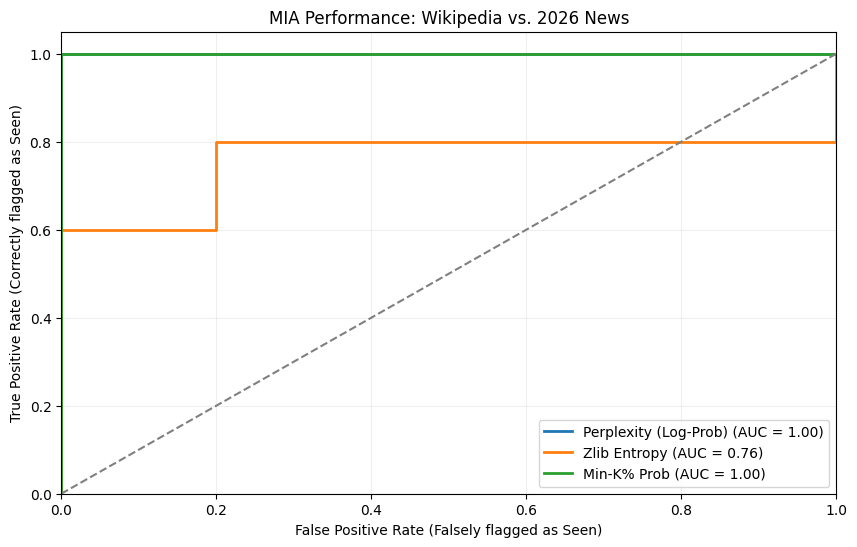

In [ ]:
# --- EVALUATION & PLOTTING ---
methods = {
    "Perplexity (Log-Prob)": score_ppl,
    "Zlib Entropy": score_zlib,
    "Min-K% Prob": score_mink
}

plt.figure(figsize=(10, 6))

for name, func in methods.items():
    scores = [func(t) for t in all_texts]
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
    print(f"{name} AUC: {roc_auc:.2f}")

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Falsely flagged as Seen)')
plt.ylabel('True Positive Rate (Correctly flagged as Seen)')
plt.title('MIA Performance: Wikipedia vs. 2026 News')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

Here we can see that Min-K% achieves 1.00 AUC along with Perplexity which is happening due to lesser number of examples otherwise Min-K% out performs both


# Taking It Further: Evaluating Min-K% on a Real Benchmark (WikiMIA)

The toy experiment showed the concept works in a controlled setting. Now we test it properly —
on a real model (`Pythia-2.8B`) against a real benchmark (`WikiMIA`), with real metrics (AUC),
and compare our results directly against the numbers reported in the original ICLR 2024 paper.

Loading Libraries

In [ ]:
import torch
import numpy as np
import zlib
import time
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from sklearn.metrics import roc_auc_score, roc_curve

print(f"CUDA available: {torch.cuda.is_available()}")

CUDA available: True


Loading WikiMia Dataset


In [ ]:
length = 64

dataset = load_dataset("swj0419/WikiMIA", split=f"WikiMIA_length{length}")

print(f"Dataset size: {len(dataset)}")
print(f"Columns: {dataset.column_names}")

# Separate member (label=1) and non-member (label=0) texts
texts = dataset["input"]
labels = dataset["label"]  # 1 = member (seen), 0 = non-member (unseen)

member_count = sum(labels)
non_member_count = len(labels) - member_count
print(f"Member samples:     {member_count}")
print(f"Non-member samples: {non_member_count}")


README.md: 0.00B [00:00, ?B/s]

data/WikiMIA_length128-00000-of-00001-ff(…):   0%|          | 0.00/132k [00:00<?, ?B/s]

data/WikiMIA_length256-00000-of-00001-e9(…):   0%|          | 0.00/92.9k [00:00<?, ?B/s]

data/WikiMIA_length32-00000-of-00001-6d3(…):   0%|          | 0.00/100k [00:00<?, ?B/s]

data/WikiMIA_length64-00000-of-00001-c33(…):   0%|          | 0.00/140k [00:00<?, ?B/s]

Generating WikiMIA_length128 split:   0%|          | 0/250 [00:00<?, ? examples/s]

Generating WikiMIA_length256 split:   0%|          | 0/82 [00:00<?, ? examples/s]

Generating WikiMIA_length32 split:   0%|          | 0/776 [00:00<?, ? examples/s]

Generating WikiMIA_length64 split:   0%|          | 0/542 [00:00<?, ? examples/s]

Dataset size: 542
Columns: ['input', 'label']
Member samples:     284
Non-member samples: 258


Min K% Probability function

In [ ]:
def get_token_log_probs(text, model, tokenizer, device):
    """
    Feed text into the model and return per-token log probabilities.
    Uses teacher forcing: feed the real text and measure how surprised
    the model is at each actual token.
    """
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=1024).to(device)
    input_ids = inputs["input_ids"]

    with torch.no_grad():
        outputs = model(**inputs, labels=input_ids)
        # logits shape: [1, seq_len, vocab_size]
        logits = outputs.logits

    # Shift: logits[i] predicts token[i+1]
    shift_logits = logits[0, :-1, :]       # predictions for positions 1..N
    shift_labels = input_ids[0, 1:]        # actual tokens at positions 1..N

    # Compute log probabilities for each actual token
    log_probs = torch.nn.functional.log_softmax(shift_logits, dim=-1)
    token_log_probs = log_probs[range(len(shift_labels)), shift_labels]

    return token_log_probs.cpu().numpy()


def mink_prob_score(text, model, tokenizer, device, k=20):
    """
    Min-K% Prob (paper's proposed method).

    Steps:
    1. Get log probability of every token
    2. Select the bottom k% (lowest probability tokens)
    3. Average their log probabilities

    Higher score = model is confident even on hard tokens = likely MEMBER
    Lower score  = model struggles on hard tokens = likely NON-MEMBER
    """
    token_log_probs = get_token_log_probs(text, model, tokenizer, device)
    if len(token_log_probs) == 0:
        return 0.0

    # Select bottom k% tokens (most negative log probs = lowest probability)
    k_count = max(1, int(len(token_log_probs) * k / 100))
    sorted_log_probs = np.sort(token_log_probs)  # ascending = lowest prob first
    min_k_log_probs = sorted_log_probs[:k_count]

    return float(np.mean(min_k_log_probs))


print("Scoring function defined.")

Scoring function defined.


Loading Model

In [ ]:
model_name = "EleutherAI/pythia-2.8b"
MODEL_NAME = model_name

print(f"Loading model: {model_name}")
start = time.time()

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype="auto"
)
model.eval()

# device_map="auto" places layers on GPU/CPU automatically
device = next(model.parameters()).device

print(f"Model loaded in {time.time() - start:.1f}s")
print(f"Device: {device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M")

Loading model: EleutherAI/pythia-2.8b


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/5.68G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

Model loaded in 66.1s
Device: cuda:0
Parameters: 2775M


Evaluation on WikiMIA Dataset

In [ ]:
def evaluate_dataset(texts, labels, model, tokenizer, device, k=20, max_samples=None):
    """
    Run Min-K% Prob on the dataset and return scores + labels.
    Set max_samples to limit evaluation (useful for quick testing).
    """
    if max_samples:
        texts = texts[:max_samples]
        labels = labels[:max_samples]

    mink_scores = []
    timing = []

    print(f"Evaluating {len(texts)} samples with Min-K% Prob (k={k})...")
    for i, text in enumerate(texts):
        t0 = time.time()
        mink_scores.append(mink_prob_score(text, model, tokenizer, device, k=k))
        timing.append(time.time() - t0)

        if (i + 1) % 50 == 0:
            print(f"  [{i+1}/{len(texts)}] avg time per sample: {np.mean(timing):.2f}s")

    print(f"Done. Total time: {sum(timing):.1f}s | Avg per sample: {np.mean(timing):.2f}s")
    return mink_scores, labels, timing


# Run evaluation (set max_samples=100 for a quick test; remove for full dataset)
mink_scores, true_labels, timing = evaluate_dataset(
    texts, labels, model, tokenizer, device, k=20, max_samples=100
)

Evaluating 100 samples with Min-K% Prob (k=20)...
  [50/100] avg time per sample: 0.05s
  [100/100] avg time per sample: 0.05s
Done. Total time: 4.5s | Avg per sample: 0.05s


Calculating AUC of class original and comparing it with research paper

In [ ]:
auc = roc_auc_score(true_labels, mink_scores)

print("\n=== AUC Results ===")
print(f"{'Method':<20} {'AUC (ours)':>12} {'AUC (paper)':>12}")
print("-" * 46)
print(f"{'Min-K% Prob':<20} {auc:>12.4f} {'0.67':>12}")
print("\n(Paper value is for Pythia-2.8B on WikiMIA length-128, original setting)")


=== AUC Results ===
Method                 AUC (ours)  AUC (paper)
----------------------------------------------
Min-K% Prob                0.5956         0.67

(Paper value is for Pythia-2.8B on WikiMIA length-128, original setting)


ROC Curve Visulization

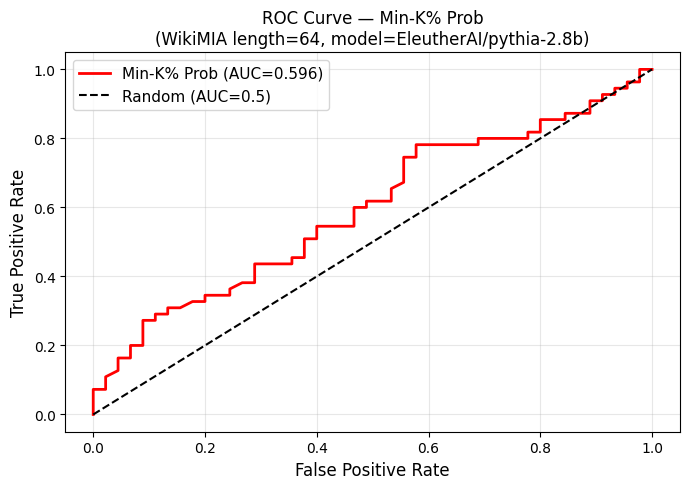

In [ ]:
fpr, tpr, _ = roc_curve(true_labels, mink_scores)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="red", label=f"Min-K% Prob (AUC={auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC=0.5)")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title(f"ROC Curve — Min-K% Prob\n(WikiMIA length={length}, model={MODEL_NAME})", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve_mink.png", dpi=150)
plt.show()

Hyperparameter Analysis: Sensitivity of k

The paper found **k=20** works best. Here we sweep over k values to verify this.

In [ ]:
k_values = [10, 20, 30, 40, 50]
k_aucs = []

print("Sweeping k values...")
for k in k_values:
    k_scores = [
        mink_prob_score(t, model, tokenizer, device, k=k)
        for t in texts[:100]  # use subset for speed
    ]
    auc = roc_auc_score(true_labels[:100], k_scores)
    k_aucs.append(auc)
    print(f"  k={k:>3}% → AUC = {auc:.4f}")

best_k = k_values[np.argmax(k_aucs)]
print(f"\nBest k = {best_k}% (AUC = {max(k_aucs):.4f})")
print(f"Paper reports best k = 20%")

Sweeping k values...
  k= 10% → AUC = 0.6265
  k= 20% → AUC = 0.5956
  k= 30% → AUC = 0.5630
  k= 40% → AUC = 0.5390
  k= 50% → AUC = 0.5246

Best k = 10% (AUC = 0.6265)
Paper reports best k = 20%


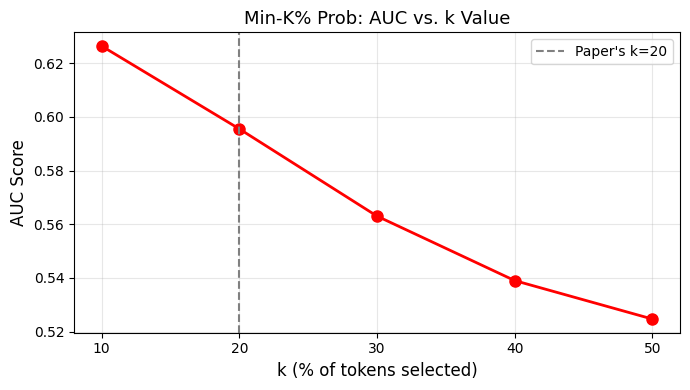

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(k_values, k_aucs, marker="o", color="red", linewidth=2, markersize=8)
plt.axvline(x=20, color="gray", linestyle="--", label="Paper's k=20")
plt.xlabel("k (% of tokens selected)", fontsize=12)
plt.ylabel("AUC Score", fontsize=12)
plt.title("Min-K% Prob: AUC vs. k Value", fontsize=13)
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("k_sensitivity.png", dpi=150)
plt.show()

## Scaling Up: Min-K% Across Multiple Models & Text Lengths

So far we evaluated Min-K% on a single model (`Pythia-2.8B`) at a fixed text length (`64`). But does detection quality improve with model size? Does longer text give Min-K% more signal to work with?

Here we sweep over **three Pythia model sizes** and **two WikiMIA length splits** to find out:

| Variable | Values |
|---|---|
| **Model size** | `pythia-70m`, `pythia-160m`, `pythia-410m` |
| **Text length** | `WikiMIA_length32`, `WikiMIA_length128` |

Each cell in the grid is scored independently using our `mink_prob_score` function, and the results are compared in a grouped bar chart.

> **Expected trend:** Larger models → stronger memorization → higher AUC. Longer texts → more tokens for Min-K% to operate on → more reliable signal.


Loading: EleutherAI/pythia-70m


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  WikiMIA_length32: AUC = 0.4052
  WikiMIA_length128: AUC = 0.5922

Loading: EleutherAI/pythia-160m


config.json:   0%|          | 0.00/569 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/911M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

  WikiMIA_length32: AUC = 0.5022
  WikiMIA_length128: AUC = 0.5969

Model                              L=32      L=128
----------------------------------------------------
pythia-70m                       0.4052     0.5922
pythia-160m                      0.4545     0.5779
pythia-410m                      0.5022     0.5969


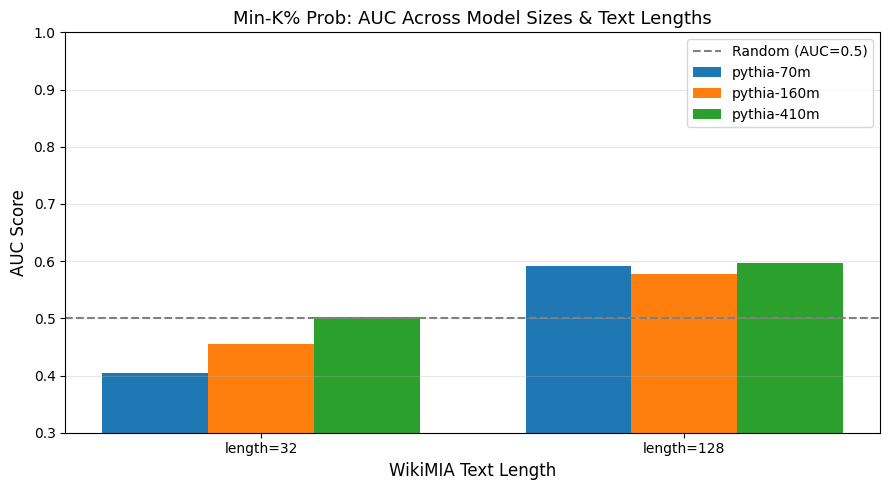

In [ ]:
import gc

models_to_test = [
    "EleutherAI/pythia-70m",
    "EleutherAI/pythia-160m",
    "EleutherAI/pythia-410m",
]
lengths_to_test = [32, 128]

results = {}  # {model_name: {length: auc}}

for model_name in models_to_test:
    print(f"\n{'='*60}")
    print(f"Loading: {model_name}")

    cur_tokenizer = AutoTokenizer.from_pretrained(model_name)
    cur_model = AutoModelForCausalLM.from_pretrained(
        model_name, device_map="auto", torch_dtype="auto"
    )
    cur_model.eval()
    cur_device = next(cur_model.parameters()).device

    results[model_name] = {}

    for length in lengths_to_test:
        dataset = load_dataset("swj0419/WikiMIA", split=f"WikiMIA_length{length}")
        texts  = dataset["input"][:100]
        labels = dataset["label"][:100]

        scores = [
            mink_prob_score(t, cur_model, cur_tokenizer, cur_device, k=20)
            for t in texts
        ]
        auc_val = roc_auc_score(labels, scores)
        results[model_name][length] = round(auc_val, 4)
        print(f"  WikiMIA_length{length}: AUC = {auc_val:.4f}")

    # Free GPU memory before loading the next model
    del cur_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ── Summary table ──────────────────────────────────────────
print("\n" + "="*52)
print(f"{'Model':<28} {'L=32':>10} {'L=128':>10}")
print("-"*52)
for model_name in models_to_test:
    short = model_name.split("/")[-1]
    print(f"{short:<28} {results[model_name][32]:>10.4f} {results[model_name][128]:>10.4f}")

# ── Grouped bar chart ──────────────────────────────────────
model_labels = [m.split("/")[-1] for m in models_to_test]
x     = np.arange(len(lengths_to_test))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for i, (model_name, label) in enumerate(zip(models_to_test, model_labels)):
    aucs = [results[model_name][l] for l in lengths_to_test]
    ax.bar(x + i * width, aucs, width, label=label)

ax.set_xlabel("WikiMIA Text Length", fontsize=12)
ax.set_ylabel("AUC Score", fontsize=12)
ax.set_title("Min-K% Prob: AUC Across Model Sizes & Text Lengths", fontsize=13)
ax.set_xticks(x + width)
ax.set_xticklabels([f"length={l}" for l in lengths_to_test])
ax.axhline(y=0.5, color="gray", linestyle="--", label="Random (AUC=0.5)")
ax.legend()
ax.set_ylim(0.3, 1.0)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()